In [8]:
import pandas as pd

kolumny = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes',
    'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
    'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
    'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'sSame_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

url_train = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain%2B.csv"

print("Pobieranie danych.")
#df = pd.read_csv(url_train, header=None)
df = pd.read_csv(url_train, header=None, names=kolumny)

print(f"Gotowe! Zbiór danych ma {df.shape[0]} wierszy i {df.shape[1]} kolumn.")
df.head()

Pobieranie danych.
Gotowe! Zbiór danych ma 125973 wierszy i 43 kolumn.


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [9]:
#df = df.drop(columns=[42])
df = df.drop(columns=['difficulty'])

#df['label'] = df[41].apply(lambda x: 0 if x == 'normal' else 1)
#df = df.drop(columns=[41]) 
df['is_attack'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)
df = df.drop(columns=['label'])

#df = pd.get_dummies(df, columns=[1, 2, 3], dtype=int)
df = pd.get_dummies(df, columns=['protocol_type', 'service', 'flag'], dtype=int)
print(f"Nowy kształt tabeli to: {df.shape[0]} wierszy i {df.shape[1]} kolumn.")
df.head()

Nowy kształt tabeli to: 125973 wierszy i 123 kolumn.


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,491,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,146,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,232,8153,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
4,0,199,420,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier


# Dzielenie danych na zbiór treningowy i testowy
#X = df.drop(columns=['label'])
#y = df['label']
X = df.drop(columns=['is_attack'])
y = df['is_attack']
X.columns = X.columns.astype(str)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Trenowanie modelu bazowego (Drzewo Decyzyjne)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train) 

# Trenowanie modelu głównego (Las Losowy)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Koniec nauczania")

Koniec nauczania



--- Wyniki dla: Drzewo Decyzyjne ---
Dokładność (Accuracy):  0.9984
Precyzja (Precision): 0.9982
Czułość (Recall):   0.9984
F1-Score:             0.9983

--- Wyniki dla: Las Losowy (Random Forest) ---
Dokładność (Accuracy):  0.9989
Precyzja (Precision): 0.9996
Czułość (Recall):   0.9981
F1-Score:             0.9989

Generowanie wykresu Macierzy Błędów dla Lasu Losowego...


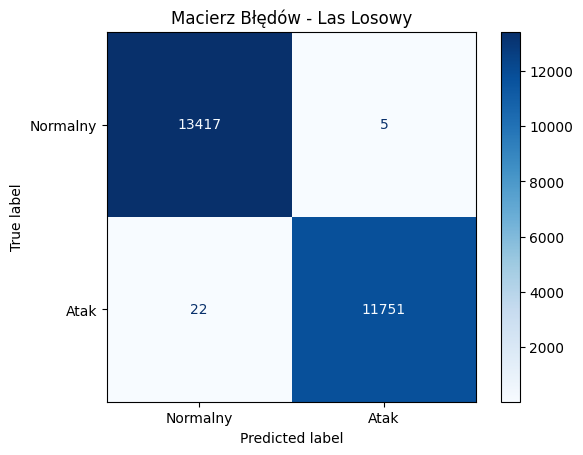

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

dt_predictions = dt_model.predict(X_test)

rf_predictions = rf_model.predict(X_test)

def print_metrics(nazwa_modelu, y_true, y_pred):
    print(f"\n--- Wyniki dla: {nazwa_modelu} ---")
    print(f"Dokładność (Accuracy):  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precyzja (Precision): {precision_score(y_true, y_pred):.4f}")
    print(f"Czułość (Recall):   {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:             {f1_score(y_true, y_pred):.4f}")

print_metrics("Drzewo Decyzyjne", y_test, dt_predictions)
print_metrics("Las Losowy (Random Forest)", y_test, rf_predictions)

print("\nGenerowanie wykresu Macierzy Błędów dla Lasu Losowego...")
cm = confusion_matrix(y_test, rf_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normalny', 'Atak'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Macierz Błędów - Las Losowy")
plt.show()

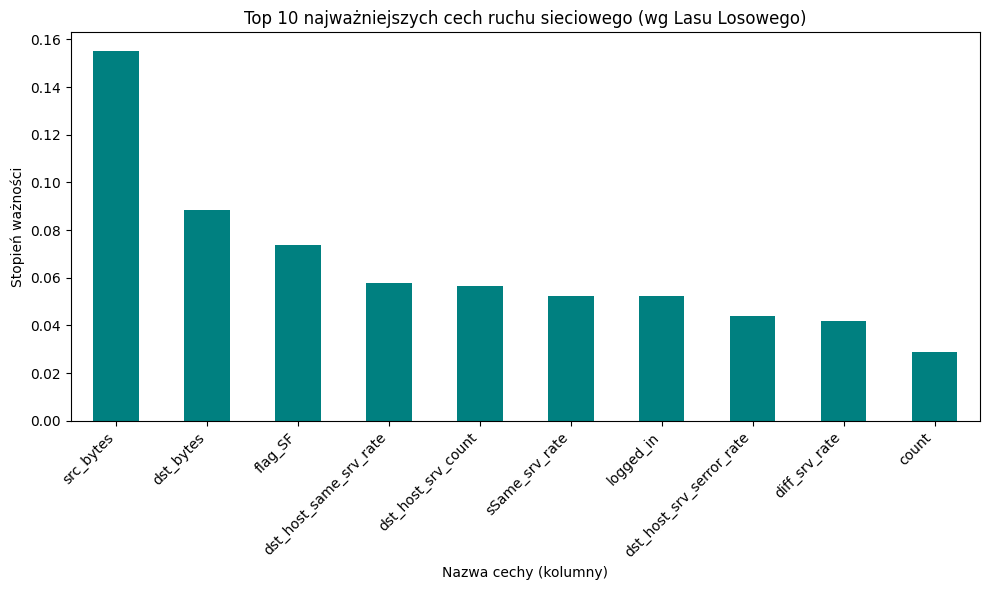

In [14]:
import pandas as pd
import numpy as np

# ważności cech (Feature Importance)
importances = rf_model.feature_importances_
feature_names = X.columns

forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

top_10_features = forest_importances.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
top_10_features.plot.bar(ax=ax, color='teal')
ax.set_title("Top 10 najważniejszych cech ruchu sieciowego (wg Lasu Losowego)")
ax.set_ylabel("Stopień ważności")
ax.set_xlabel("Nazwa cechy (kolumny)")
plt.xticks(rotation=45, ha='right')
fig.tight_layout()
plt.show()